In [1]:
from dataclasses import replace
import tabulate

from config.experiment import ExperimentConfig
from experiments import load_config
from config.task import generate_task_configs
from utils.plot import Metric, plot_metrics_vs_perturbation, get_metrics, shorten_model_name, strip_hf_org

In [2]:
def get_config(cfg_name: str) -> ExperimentConfig:
    exp_cfg = load_config(cfg_name)

    return ExperimentConfig(
        train = replace(exp_cfg.train, save_folder = exp_cfg.train.save_folder.parent / "paper"),
        eval = replace(exp_cfg.eval, results_folder = exp_cfg.eval.results_folder.parent / "paper"),
    )

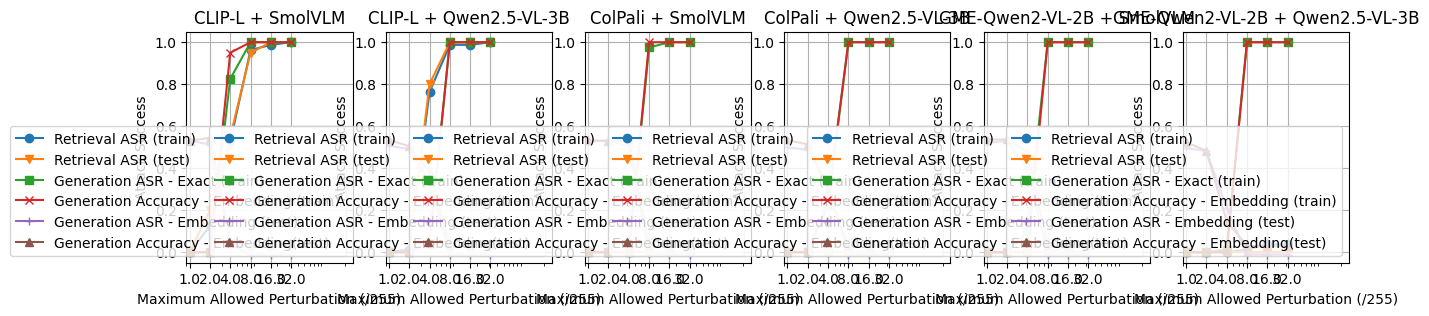

In [3]:
"""
to test perturbation plot (full x-axis)
"""
exp_config = get_config("paper_perturbation_plot")

plot_metrics_vs_perturbation(exp_config, metrics_to_show=[Metric.RETRIEVAL_ASR_TRAIN, Metric.RETRIEVAL_ASR_TEST, Metric.GENERATION_ASR_EXACT_TRAIN, Metric.GENERATION_ASR_EXACT_TEST, Metric.Generation_ACC_EMBED_GT_TRAIN, Metric.Generation_ACC_EMBED_GT_TEST], ret_topk_idx=0, gen_topk_idx=0)

In [8]:
def make_all_metric_table(config_name: str):
    exp_config = get_config(config_name)
    metrics_to_show = [m for m in Metric]

    task_configs = generate_task_configs(exp_config, include_eval=True)

    table = []
    for task_config in task_configs:
        row = {
            "dataset": strip_hf_org(task_config.ds_name),
            "embedder": shorten_model_name(task_config.model_name_embs[0]),
            "vlm": shorten_model_name(task_config.vlm.models[0]),
        }
        if task_config.eval_emb_name:
            row["eval emb"] = shorten_model_name(task_config.eval_emb_name)
        if task_config.eval_vlm_name:
            row["eval vlm"] = shorten_model_name(task_config.eval_vlm_name)

        metrics, _ = get_metrics(
            exp_config=exp_config,
            task_config=task_config,
            metrics_to_show=metrics_to_show,
            ret_topk_idx=0,
            gen_topk_idx=0,
            loss_idx=0,
        )
        metrics = {k.value: v for k, v in metrics.items()}
        row.update(metrics)
        table.append(row)
    # return tabulate.tabulate(table, headers="keys", tablefmt="latex", showindex="never")
    return tabulate.tabulate(table, headers="keys", tablefmt="html", showindex="always")

In [9]:
make_all_metric_table("paper_non_targeted")

,dataset,embedder,vlm,eval emb,eval vlm,Clean Retrieval Recall,Poisoned Retrieval Recall,Retrieval ASR (train),Retrieval ASR (test),Generation ASR - Exact (train),Generation ASR - Embedding (train),Generation ASR - Embedding (test),Generation Accuracy - Embedding (train),Generation ASR - Exact (test),Generation Accuracy - Embedding(test)
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,SmolVLM,0.21,0.02,0.95,1,1,1,-0.0109306,1,1,0.0301554
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,Qwen2.5-VL-3B,0.21,0.02,0.95,1,0,-0.0187519,0.504184,0,-0.0204002,0.570046
2,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,ColPali,SmolVLM,0,0,0,0,1,1,-0.0109306,1,1,0.0301554
3,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,ColPali,Qwen2.5-VL-3B,0,0,0,0,0,-0.028838,0.528488,0,-0.00260906,0.551578
4,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0,1,1,-0.0109306,1,1,0.0301554
5,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0,0,-0.0169058,0.508712,0,-0.0246796,0.544255
6,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,SmolVLM,0.21,0.01,0.9875,1,0,-0.0352647,0.53168,0,-0.0220598,0.539126
7,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,0.21,0.01,0.9875,1,1,1,-0.0109306,1,1,0.0301554
8,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,ColPali,SmolVLM,0,0,0,0,0,-0.0449022,0.533254,0,-0.0333702,0.488119
9,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,ColPali,Qwen2.5-VL-3B,0,0,0,0,1,1,-0.0109306,1,1,0.0301554


In [10]:
make_all_metric_table("paper_targeted_attacks_oneQ_oneA")

,dataset,embedder,vlm,eval emb,eval vlm,Clean Retrieval Recall,Poisoned Retrieval Recall,Retrieval ASR (train),Retrieval ASR (test),Generation ASR - Exact (train),Generation ASR - Embedding (train),Generation ASR - Embedding (test),Generation Accuracy - Embedding (train),Generation ASR - Exact (test),Generation Accuracy - Embedding(test)
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,SmolVLM,0.21,0.21,0.0375,0,0,0.504682,0.49941,0,0.530842,0.530842
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.0375,0,0,0.510092,0.513683,0,0.524818,0.524818
2,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,ColPali,SmolVLM,0,0,0,0,0.0125,0.519435,0.513573,0,0.51212,0.51212
3,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,ColPali,Qwen2.5-VL-3B,0,0,0,0,0,0.50505,0.508435,0,0.548689,0.548689
4,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0,0.0125,0.536106,0.530242,0,0.504139,0.504139
5,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0,0,0.510073,0.513999,0,0.548562,0.548562
6,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,SmolVLM,0.21,0.21,0.0375,0,0,0.529689,0.532769,0,0.540812,0.540812
7,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.0375,0,0.0125,0.537125,0.531261,0,0.508687,0.508687
8,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,ColPali,SmolVLM,0,0,0,0,0,0.536335,0.538369,0,0.547864,0.547864
9,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,ColPali,Qwen2.5-VL-3B,0,0,0,0,0.0125,0.522778,0.516914,0,0.529601,0.529601


In [11]:
make_all_metric_table("paper_targeted_attacks_multiQ_oneA")

,dataset,embedder,vlm,Clean Retrieval Recall,Poisoned Retrieval Recall,Retrieval ASR (train),Retrieval ASR (test),Generation ASR - Exact (train),Generation ASR - Embedding (train),Generation ASR - Embedding (test),Generation Accuracy - Embedding (train),Generation ASR - Exact (test),Generation Accuracy - Embedding(test)
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.075,0,0.0625,0.502053,0.435105,0,0.431064,0.431064
1,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0,0,0,0,0,0.494333,0.503792,0,0.519195,0.519195
2,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.57,0.0375,0,0.0625,0.462002,0.395552,0,0.476775,0.476775


In [12]:
make_all_metric_table("paper_targeted_attacks_multiQ_multiA")

,dataset,embedder,vlm,Clean Retrieval Recall,Poisoned Retrieval Recall,Retrieval ASR (train),Retrieval ASR (test),Generation ASR - Exact (train),Generation ASR - Embedding (train),Generation ASR - Embedding (test),Generation Accuracy - Embedding (train),Generation ASR - Exact (test),Generation Accuracy - Embedding(test)
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.05,0,0.025,0.538011,0.525325,0,0.510006,0.510006
1,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0,0,0,0,0,0.524412,0.524395,0,0.504887,0.504887
2,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.57,0.0125,0,0.025,0.522753,0.510065,0,0.488441,0.488441
